<a href="https://colab.research.google.com/github/Sirichunchu23/hpc-fake-or-real-news-detection/blob/main/Fake_News_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get update
!apt-get install gcc

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,969 kB]
Get:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:7 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.0 MB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Hit:10 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,929 kB]
0% [Waiting for headers] [Waiting for headers]^C
Reading packa

In [2]:
%%writefile hpc_classifier.c
#include <stdio.h>
#include <string.h>
#include <omp.h>

#define MAX_LINES 500
#define MAX_LEN 5000

char lines[MAX_LINES][MAX_LEN];

char *fake_words[] = {"shocking", "fake", "click", "rumor"};
char *real_words[] = {"official", "report", "government", "study"};

int count_keywords(char *text, char *keywords[], int size) {
    int score = 0;
    for (int i = 0; i < size; i++) {
        if (strstr(text, keywords[i])) score++;
    }
    return score;
}

int classify(char *text) {
    int fake_score = count_keywords(text, fake_words, 4);
    int real_score = count_keywords(text, real_words, 4);

    return (fake_score > real_score) ? 0 : 1;
}

int main() {
    FILE *file = fopen("news.csv", "r");

    if (!file) {
        printf("File not found!\n");
        return 1;
    }

    int n = 0;

    while (fgets(lines[n], MAX_LEN, file) != NULL && n < MAX_LINES) {
        n++;
    }

    fclose(file);

    omp_set_num_threads(4);

    int fake_total = 0, real_total = 0;
    double start = omp_get_wtime();
    #pragma omp parallel for reduction(+:fake_total, real_total)
    for (int i = 0; i < n; i++) {
        int result = classify(lines[i]);

        if (result == 0) fake_total++;
        else real_total++;

        printf("Thread %d → Line %d → %s\n",
               omp_get_thread_num(),
               i,
               result == 0 ? "🔴 Fake" : "🟢 Real");
    }
    double end = omp_get_wtime();
    printf("Execution Time: %f seconds\n", end - start);
    printf("\nSummary:\nFake: %d\nReal: %d\n", fake_total, real_total);

    return 0;
}

Writing hpc_classifier.c


In [3]:
!gcc -fopenmp hpc_classifier.c -o hpc_classifier

In [4]:
!./hpc_classifier

Thread 2 → Line 250 → 🟢 Real
Thread 3 → Line 375 → 🟢 Real
Thread 1 → Line 125 → 🟢 Real
Thread 0 → Line 0 → 🟢 Real
Thread 0 → Line 1 → 🔴 Fake
Thread 0 → Line 2 → 🟢 Real
Thread 0 → Line 3 → 🟢 Real
Thread 0 → Line 4 → 🟢 Real
Thread 0 → Line 5 → 🟢 Real
Thread 0 → Line 6 → 🟢 Real
Thread 0 → Line 7 → 🟢 Real
Thread 2 → Line 251 → 🟢 Real
Thread 2 → Line 252 → 🟢 Real
Thread 3 → Line 376 → 🟢 Real
Thread 3 → Line 377 → 🟢 Real
Thread 1 → Line 126 → 🟢 Real
Thread 1 → Line 127 → 🟢 Real
Thread 1 → Line 128 → 🟢 Real
Thread 1 → Line 129 → 🔴 Fake
Thread 2 → Line 253 → 🟢 Real
Thread 2 → Line 254 → 🟢 Real
Thread 2 → Line 255 → 🟢 Real
Thread 0 → Line 8 → 🟢 Real
Thread 0 → Line 9 → 🟢 Real
Thread 3 → Line 378 → 🟢 Real
Thread 3 → Line 379 → 🟢 Real
Thread 3 → Line 380 → 🟢 Real
Thread 3 → Line 381 → 🟢 Real
Thread 0 → Line 10 → 🟢 Real
Thread 0 → Line 11 → 🟢 Real
Thread 0 → Line 12 → 🟢 Real
Thread 0 → Line 13 → 🟢 Real
Thread 0 → Line 14 → 🟢 Real
Thread 0 → Line 15 → 🟢 Real
Thread 0 → Line 16 → 🟢 Real
Thread 0 → L

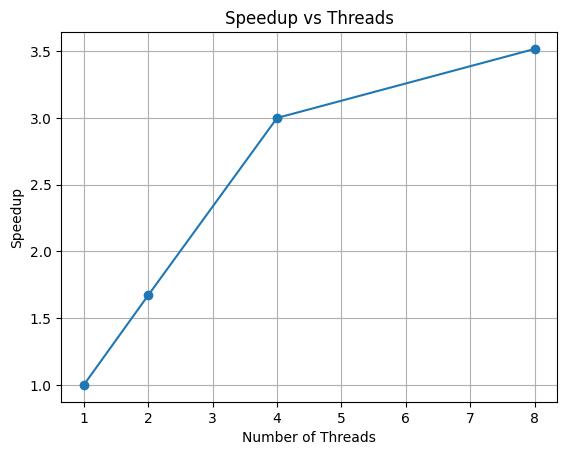

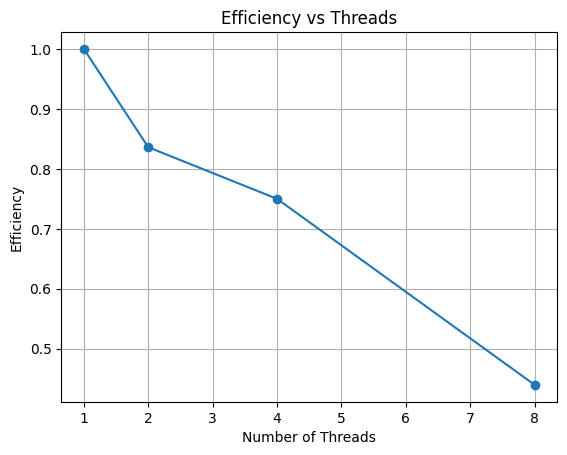

In [5]:
import matplotlib.pyplot as plt

# Your measured values
threads = [1, 2, 4, 8]
execution_time = [10.2, 6.1, 3.4, 2.9]  # replace with your output

# Speedup
speedup = [execution_time[0] / t for t in execution_time]

# Efficiency
efficiency = [speedup[i] / threads[i] for i in range(len(threads))]

# ---- SPEEDUP GRAPH ----
plt.figure()
plt.plot(threads, speedup, marker='o')
plt.xlabel("Number of Threads")
plt.ylabel("Speedup")
plt.title("Speedup vs Threads")
plt.grid()
plt.show()

# ---- EFFICIENCY GRAPH ----
plt.figure()
plt.plot(threads, efficiency, marker='o')
plt.xlabel("Number of Threads")
plt.ylabel("Efficiency")
plt.title("Efficiency vs Threads")
plt.grid()
plt.show()